# Libraries

In [312]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split

# Reading Dataset

In [220]:
filepath = '/content/drive/MyDrive/ICT_AIML Class/Datasets/House_Pricing.csv'
df_house_prices = pd.read_csv(filepath)
df_house_prices.head()

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,...,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,7129300520,14 October 2017,221900.0,3,1.00,1180.0,5650.0,1.0,No,NaN,...,7,1180.0,0,63,0,98178.0,47.5112,-122.257,1340.0,5650
1,6414100192,14 December 2017,538000.0,3,2.25,2570.0,7242.0,2.0,No,NaN,...,7,2170.0,400,67,1991,98125.0,47.7210,-122.319,1690.0,7639
2,5631500400,15 February 2016,180000.0,2,1.00,770.0,10000.0,1.0,No,NaN,...,6,770.0,0,85,0,98028.0,47.7379,-122.233,2720.0,8062
3,2487200875,14 December 2017,604000.0,4,3.00,1960.0,5000.0,1.0,No,NaN,...,7,1050.0,910,53,0,98136.0,47.5208,-122.393,1360.0,5000
4,1954400510,15 February 2016,510000.0,3,2.00,1680.0,8080.0,1.0,No,NaN,...,8,1680.0,0,31,0,98074.0,47.6168,-122.045,1800.0,7503


# Dataset Overview

In [221]:
df_house_prices.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   ID                                         21613 non-null  int64  
 1   Date House was Sold                        21613 non-null  object 
 2   Sale Price                                 21609 non-null  float64
 3   No of Bedrooms                             21613 non-null  int64  
 4   No of Bathrooms                            21609 non-null  float64
 5   Flat Area (in Sqft)                        21604 non-null  float64
 6   Lot Area (in Sqft)                         21604 non-null  float64
 7   No of Floors                               21613 non-null  float64
 8   Waterfront View                            21613 non-null  object 
 9   No of Times Visited                        2124 non-null   object 
 10  Condition of the House

In [222]:
df_house_prices.shape

(21613, 21)

In [223]:
for i in df_house_prices.columns:
  print(df_house_prices[i].value_counts())

ID
795000620     3
7520000695    2
7200179       2
3904100089    2
6308000010    2
             ..
5602000275    1
1786200010    1
1525079069    1
126049167     1
1211000185    1
Name: count, Length: 21436, dtype: int64
Date House was Sold
15 April 2016        2231
14 July 2017         2211
14 June 2017         2180
14 August 2017       1940
14 October 2017      1878
15 March 2016        1875
14 September 2017    1774
14 May 2017          1768
14 December 2017     1471
14 November 2017     1411
15 February 2016     1250
15 January 2016       978
15 May 2016           646
Name: count, dtype: int64
Sale Price
350000.0    172
450000.0    171
550000.0    159
500000.0    152
425000.0    150
           ... 
357186.0      1
747450.0      1
589999.0      1
402723.0      1
999999.0      1
Name: count, Length: 3625, dtype: int64
No of Bedrooms
3     9824
4     6882
2     2760
5     1601
6      272
1      199
7       38
0       13
8       13
9        6
10       3
11       1
33       1
Name: count

In [224]:
df_house_prices.describe()

,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
count,2.161300e+04,2.160900e+04,21613.000000,21609.000000,21604.000000,2.160400e+04,21613.000000,21613.000000,21610.000000,21613.000000,21613.000000,21613.000000,21612.000000,21612.000000,21612.000000,21612.000000,21613.000000
mean,4.580302e+09,5.401984e+05,3.370842,2.114732,2079.931772,1.510776e+04,1.494309,7.623467,1788.344193,291.509045,46.994864,84.402258,98077.937766,47.560048,-122.213892,1986.538914,12768.455652
std,2.876566e+09,3.673890e+05,0.930062,0.770138,918.487597,4.142827e+04,0.539989,1.105439,827.982604,442.575043,29.373411,401.679240,53.505425,0.138565,0.140830,685.404255,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,1.000000,290.000000,0.000000,3.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1429.250000,5.040000e+03,1.000000,7.000000,1190.000000,0.000000,21.000000,0.000000,98033.000000,47.470975,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.617500e+03,1.500000,7.000000,1560.000000,0.000000,43.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068825e+04,2.000000,8.000000,2210.000000,560.000000,67.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,10.000000,9410.000000,4820.000000,118.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [225]:
df_house_prices.columns.tolist()

['ID',
 'Date House was Sold',
 'Sale Price',
 'No of Bedrooms',
 'No of Bathrooms',
 'Flat Area (in Sqft)',
 'Lot Area (in Sqft)',
 'No of Floors',
 'Waterfront View',
 'No of Times Visited',
 'Condition of the House',
 'Overall Grade',
 'Area of the House from Basement (in Sqft)',
 'Basement Area (in Sqft)',
 'Age of House (in Years)',
 'Renovated Year',
 'Zipcode',
 'Latitude',
 'Longitude',
 'Living Area after Renovation (in Sqft)',
 'Lot Area after Renovation (in Sqft)']

# Data Preprocessing

In [226]:
# 1. Missing
# 2. Outlier
# 3. Duplicate
# 4. Scaling
# 5. Encoding

# Clean data

In [227]:
# 1. Missing target values
# 2. Duplicates
# 3. Datatypes and invalid values
# 4. Missing feature values
# 5. Outlier handling

## Data Cleaning

### Missing Value Identification

In [228]:
df_house_prices.isna().sum()

,0
ID,0
Date House was Sold,0
Sale Price,4
No of Bedrooms,0
No of Bathrooms,4
Flat Area (in Sqft),9
Lot Area (in Sqft),9
No of Floors,0
Waterfront View,0
No of Times Visited,19489


### Dropping Redundant Columns

In [229]:
missing_count = df_house_prices['No of Times Visited'].isna().sum()
total = df_house_prices.shape[0]
percentage_missing_values = (missing_count/total)*100
print(f"Percentage of missing values in 'No of Times Visited' is: {percentage_missing_values}%")

Percentage of missing values in 'No of Times Visited' is: 90.17258131680008%


In [230]:
# 'No of Times Visited' has too many missing values (>20% ??). So we drop it
df_house_prices.drop(columns=['No of Times Visited'], axis=1, inplace=True)

In [231]:
# After dropping the redundant column
df_house_prices.shape

(21613, 20)

### Dropping Rows where the Target Col has Missing Values

In [232]:
# The target column 'Sale Price' has 4 missing values
# These shouldn't be replaced, instead remove those 4 rows

# Filtering those rows where the the target col has Null values into a df
df_house_prices[df_house_prices['Sale Price'].isna()]

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
90,2791500270,14 May 2017,NaN,4,2.5,1980.0,7403.0,2.0,No,Fair,7,1980.0,0,30,0,98023.0,47.2897,-122.372,1980.0,7510
168,3261020370,14 June 2017,NaN,3,2.5,2680.0,9750.0,1.0,No,Good,8,1610.0,1070,39,0,98034.0,47.7028,-122.231,2480.0,8750
21456,3362401761,15 February 2016,NaN,2,1.5,1020.0,1049.0,3.0,No,Fair,8,1020.0,0,10,0,98103.0,47.6800,-122.348,1350.0,1395
21522,603000555,15 March 2016,NaN,6,3.0,2390.0,4000.0,2.0,No,Fair,7,2390.0,0,4,0,98118.0,47.5173,-122.286,1680.0,5000


In [233]:
# Before dropping the rows
df_house_prices.shape

(21613, 20)

In [234]:
# Using subset= to specify the column to dropna()

df_house_prices.dropna(subset=['Sale Price'], inplace=True)

In [235]:
# After dropping the 4 rows
df_house_prices.shape

(21609, 20)

### Duplicates Handling

In [236]:
df_house_prices.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
21608,False
21609,False
21610,False
21611,False


In [237]:
df_house_prices.duplicated().sum()

np.int64(0)

In [238]:
# There are no duplicate rows
# So no need to drop

### Checking and Dropping Rows where Cols have less Missing Values

In [239]:
all_missing = df_house_prices.isna().sum()
missing_only = all_missing[all_missing > 0]         # Filtering only those columns which have isna().sum() > 0 as a series

df_house_prices.loc[:, df_house_prices.isna().sum() > 0].info()     # df.loc() is label based indexing
                # here ':' selects all rows, the parameter after that is the condition to select the required column
print(missing_only)

<class 'pandas.core.frame.DataFrame'>
Index: 21609 entries, 0 to 21612
Data columns (total 8 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   No of Bathrooms                            21605 non-null  float64
 1   Flat Area (in Sqft)                        21600 non-null  float64
 2   Lot Area (in Sqft)                         21600 non-null  float64
 3   Area of the House from Basement (in Sqft)  21606 non-null  float64
 4   Zipcode                                    21608 non-null  float64
 5   Latitude                                   21608 non-null  float64
 6   Longitude                                  21608 non-null  float64
 7   Living Area after Renovation (in Sqft)     21608 non-null  float64
dtypes: float64(8)
memory usage: 1.5 MB
No of Bathrooms                              4
Flat Area (in Sqft)                          9
Lot Area (in Sqft)                         

In [240]:
# Based on the missing value counts:
# 1) ['No of Bathrooms']         -  Categorical col containing  float - then use mode
# 2) ['Flat Area (in Sqft)']     -  Float, use mean/median
# 3) ['Lot Area (in Sqft)']      -  Float, use mean/median
# 4) ['Area of the House from Basement (in Sqft)']    -  Float, use mean/median
# 5) ['Zipcode']                  - Only 1 missing value
# 6) ['Latitude']                 - Only 1 missing value
# 7) ['Longitude']                - Only 1 missing value
# 8) ['Living Area after Renovation (in Sqft)']       -  Only 1 missing value

In [241]:
cols = ['Zipcode', 'Latitude', 'Longitude', 'Living Area after Renovation (in Sqft)']
df_house_prices[df_house_prices[cols].isna().any(axis=1)]     # To print df of the df where the cols have any missing value

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
586,7942601895,14 August 2017,640000.0,3,2.50,2160.0,4000.0,1.5,No,Fair,8,1960.0,200,115,2013,NaN,47.6045,-122.307,2160.0,5120
634,9550204515,14 September 2017,542000.0,2,1.00,890.0,3060.0,1.0,No,Fair,7,770.0,120,108,0,98105.0,NaN,-122.326,1760.0,4080
671,5101405124,14 September 2017,435000.0,4,2.50,1700.0,6380.0,1.0,No,Good,7,850.0,850,78,0,98115.0,47.6988,NaN,1380.0,6380
732,2619950350,14 May 2017,403000.0,3,2.75,2090.0,8354.0,2.0,No,Fair,8,2090.0,0,6,0,98019.0,47.7336,-121.965,NaN,6348


In [242]:
# Dropping rows that contain only 1 missing value per feature col

df_house_prices.dropna(subset=['Zipcode', 'Latitude', 'Longitude', 'Living Area after Renovation (in Sqft)'], inplace=True)

In [243]:
# After dropping those 4 rows
df_house_prices.shape

(21605, 20)

### Missing Value Imputation

<Axes: xlabel='Flat Area (in Sqft)', ylabel='Count'>

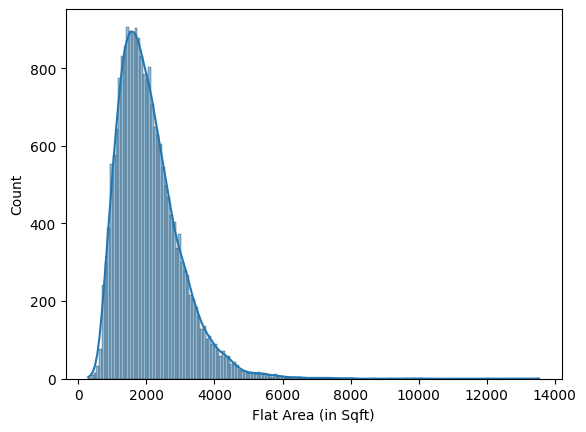

In [244]:
# 'Flat Area (in Sqft)':
# Graph is right skewed with long tail
sns.histplot(df_house_prices['Flat Area (in Sqft)'], kde=True)

<Axes: xlabel='Lot Area (in Sqft)', ylabel='Count'>

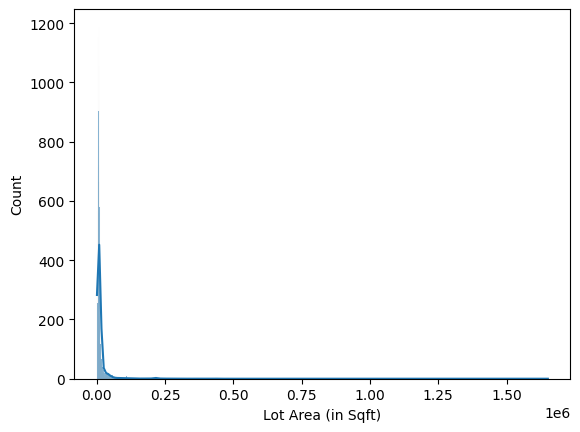

In [245]:
# 'Lot Area (in Sqft)':
# Graph is extremely-right skewed with long tail

sns.histplot(df_house_prices['Lot Area (in Sqft)'], kde=True)

<Axes: xlabel='Area of the House from Basement (in Sqft)', ylabel='Count'>

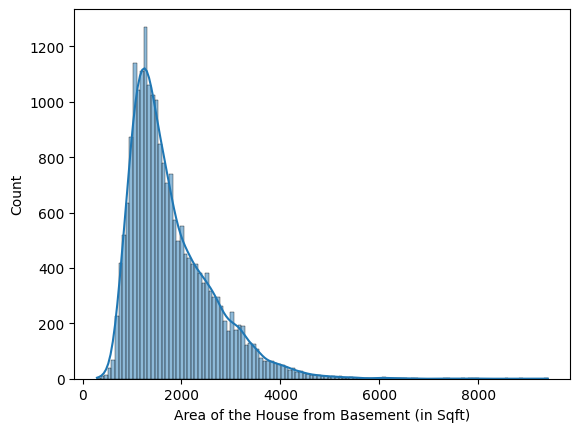

In [246]:
# 'Area of the House from Basement (in Sqft)':
# Graph is right skewed

sns.histplot(df_house_prices['Area of the House from Basement (in Sqft)'], kde=True)

In [247]:
# All numerical cols are having right-skewed plots, so we use median for imputation of missing values

cols = ['Flat Area (in Sqft)', 'Lot Area (in Sqft)', 'Area of the House from Basement (in Sqft)']

for i in cols:
  df_house_prices[i] = df_house_prices[i].fillna(df_house_prices[i].median())

# df_house_prices['Flat Area (in Sqft)'] = df_house_prices['Flat Area (in Sqft)'].fillna(df_house_prices['Flat Area (in Sqft)'].median())
# df_house_prices['Lot Area (in Sqft)'] = df_house_prices['Lot Area (in Sqft)'].fillna(df_house_prices['Lot Area (in Sqft)'].median())
# df_house_prices['Area of the House from Basement (in Sqft)'] = df_house_prices['Area of the House from Basement (in Sqft)'].fillna(df_house_prices['Area of the House from Basement (in Sqft)'].median())

In [248]:
# 'No of Bathrooms' is a categorical column. So use mode() to fill
df_house_prices['No of Bathrooms'] = df_house_prices['No of Bathrooms'].fillna(df_house_prices['No of Bathrooms'].mode()[0])

In [249]:
df_house_prices.isnull().sum()

,0
ID,0
Date House was Sold,0
Sale Price,0
No of Bedrooms,0
No of Bathrooms,0
Flat Area (in Sqft),0
Lot Area (in Sqft),0
No of Floors,0
Waterfront View,0
Condition of the House,0


### Outlier Handling

In [250]:
df_house_prices.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21605 entries, 0 to 21612
Data columns (total 20 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   ID                                         21605 non-null  int64  
 1   Date House was Sold                        21605 non-null  object 
 2   Sale Price                                 21605 non-null  float64
 3   No of Bedrooms                             21605 non-null  int64  
 4   No of Bathrooms                            21605 non-null  float64
 5   Flat Area (in Sqft)                        21605 non-null  float64
 6   Lot Area (in Sqft)                         21605 non-null  float64
 7   No of Floors                               21605 non-null  float64
 8   Waterfront View                            21605 non-null  object 
 9   Condition of the House                     21605 non-null  object 
 10  Overall Grade              

In [251]:
# Filtering numerical columns by datatype
# Dropping ID as it is a categorical col with unique values
num_cols = df_house_prices.drop(columns=['ID'], axis=1).select_dtypes(include=['int64', 'float64'])
print(num_cols.shape[1])

16


In [252]:
# Filtering categorical columns by datatype
cat_cols = df_house_prices.select_dtypes(include=['object', 'bool'])
cat_cols.columns

Index(['Date House was Sold', 'Waterfront View', 'Condition of the House'], dtype='object')

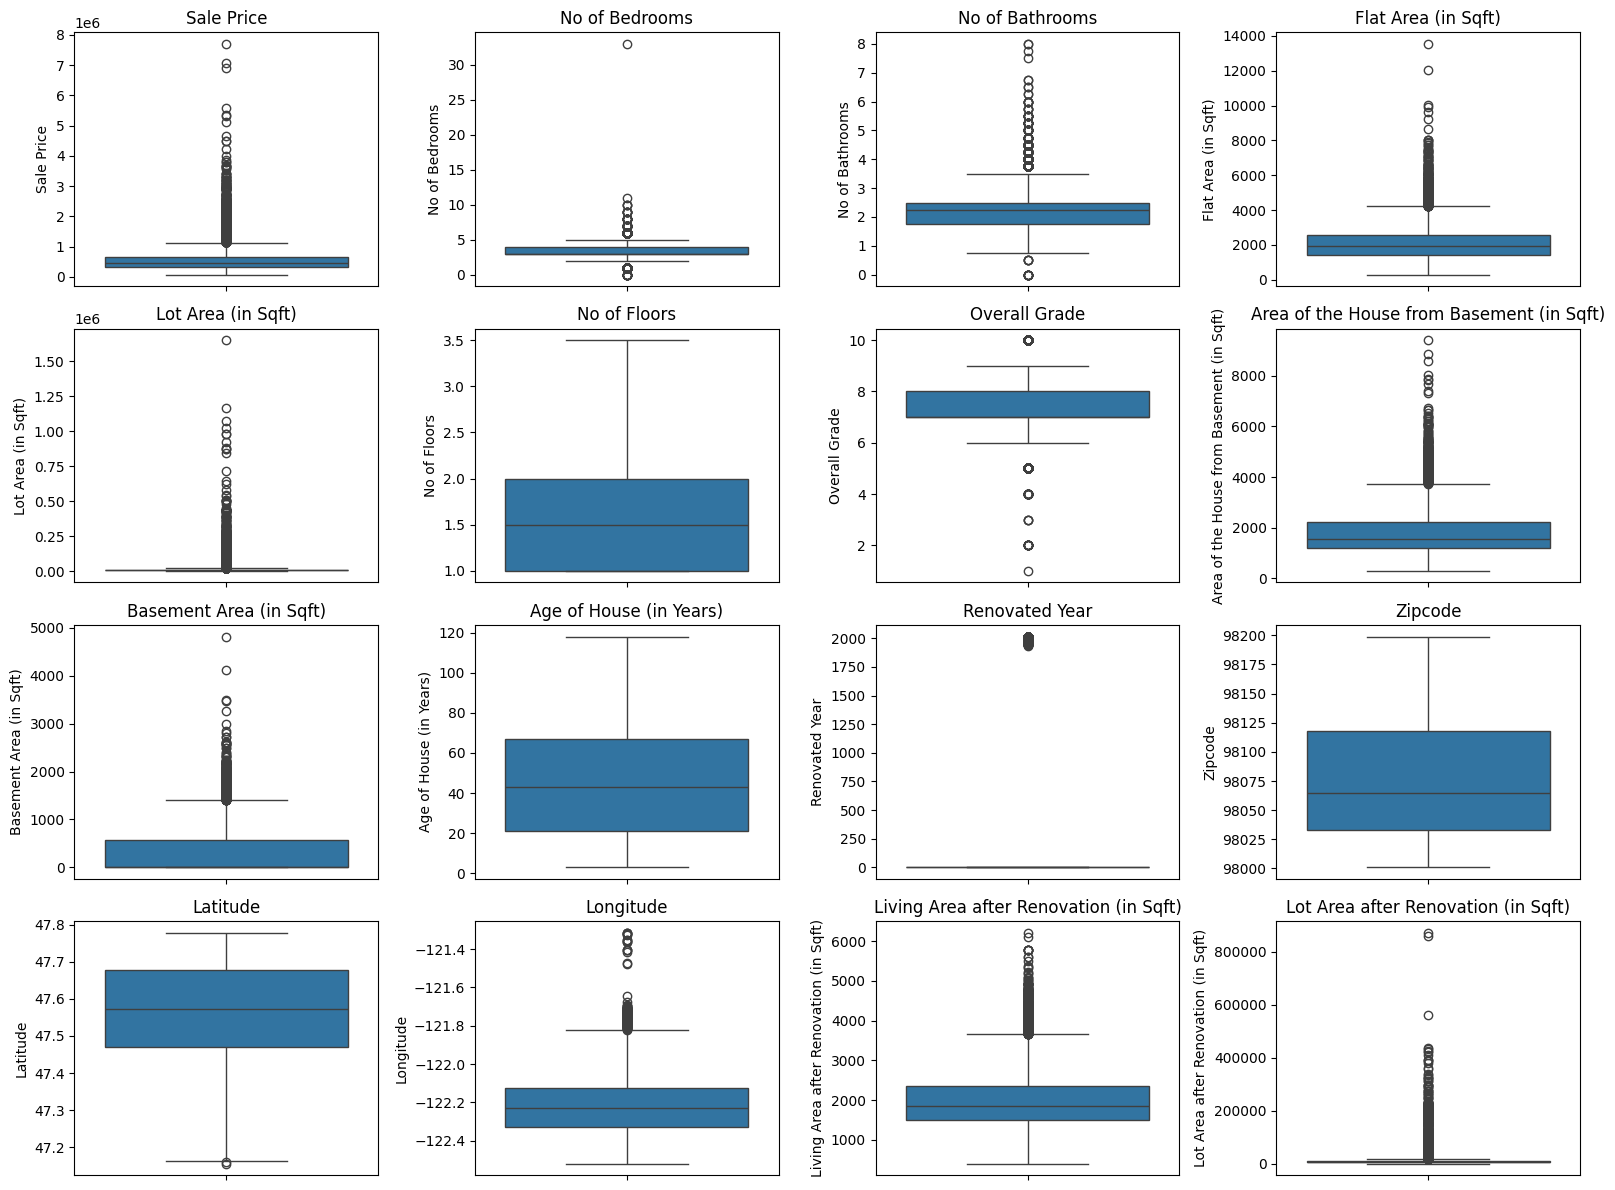

In [253]:
# Visualizing outliers by subplotting all boxplots of the columns in num_col

plt.figure(figsize=(16, 12))

i = 1
for column in num_cols:
  plt.subplot(4, 4, i)              # i only denotes the position of the boxplot while subplotting
  sns.boxplot(num_cols[column])
  plt.title(column)
  i += 1

plt.tight_layout()
plt.show()

In [254]:
num_cols.describe()

,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
count,2.160500e+04,21605.000000,21605.000000,21605.000000,2.160500e+04,21605.000000,21605.000000,21605.000000,21605.000000,21605.000000,21605.000000,21605.000000,21605.000000,21605.000000,21605.000000,21605.000000
mean,5.402050e+05,3.370840,2.114742,2079.941032,1.510820e+04,1.494237,7.623513,1788.388243,291.513307,46.994214,84.340338,98077.939088,47.560033,-122.213876,1986.590558,12771.120065
std,3.674205e+05,0.929939,0.770125,918.393347,4.142714e+04,0.539927,1.105600,827.997287,442.589231,29.367378,401.536399,53.508573,0.138561,0.140831,685.475040,27308.853462
min,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,1.000000,290.000000,0.000000,3.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,3.215000e+05,3.000000,1.750000,1430.000000,5.042000e+03,1.000000,7.000000,1190.000000,0.000000,21.000000,0.000000,98033.000000,47.470900,-122.328000,1490.000000,5100.000000
50%,4.500000e+05,3.000000,2.250000,1910.000000,7.620000e+03,1.500000,7.000000,1560.000000,0.000000,43.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,8.000000,2210.000000,560.000000,67.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10086.000000
max,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,10.000000,9410.000000,4820.000000,118.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [255]:

num_cols.columns.tolist()

['Sale Price',
 'No of Bedrooms',
 'No of Bathrooms',
 'Flat Area (in Sqft)',
 'Lot Area (in Sqft)',
 'No of Floors',
 'Overall Grade',
 'Area of the House from Basement (in Sqft)',
 'Basement Area (in Sqft)',
 'Age of House (in Years)',
 'Renovated Year',
 'Zipcode',
 'Latitude',
 'Longitude',
 'Living Area after Renovation (in Sqft)',
 'Lot Area after Renovation (in Sqft)']

In [256]:
# 'Sale Price': Is the target column. So no handling outliers

In [257]:
# 'No of Floors', 'Overall Grade', 'Zipcode', 'Latitude', 'Longitude', 'Renovated Year' => Categorical Cols containing discrete numeric data
# No need to handle outliers in these 6 cols as they are categorical cols with discrete numeric values

In [258]:
# 'Age of House (in Years)': Categorical Col with discrete int values
# Has no outliers

In [259]:
# Remaining 8 cols
num_cols_outliers = num_cols.drop(columns=['Sale Price','No of Floors', 'Overall Grade', 'Zipcode', 'Latitude', 'Longitude',
                                           'Renovated Year', 'Age of House (in Years)'], axis=1)
len(num_cols_outliers.columns.tolist())

8

In [260]:
num_cols.columns.tolist()

['Sale Price',
 'No of Bedrooms',
 'No of Bathrooms',
 'Flat Area (in Sqft)',
 'Lot Area (in Sqft)',
 'No of Floors',
 'Overall Grade',
 'Area of the House from Basement (in Sqft)',
 'Basement Area (in Sqft)',
 'Age of House (in Years)',
 'Renovated Year',
 'Zipcode',
 'Latitude',
 'Longitude',
 'Living Area after Renovation (in Sqft)',
 'Lot Area after Renovation (in Sqft)']

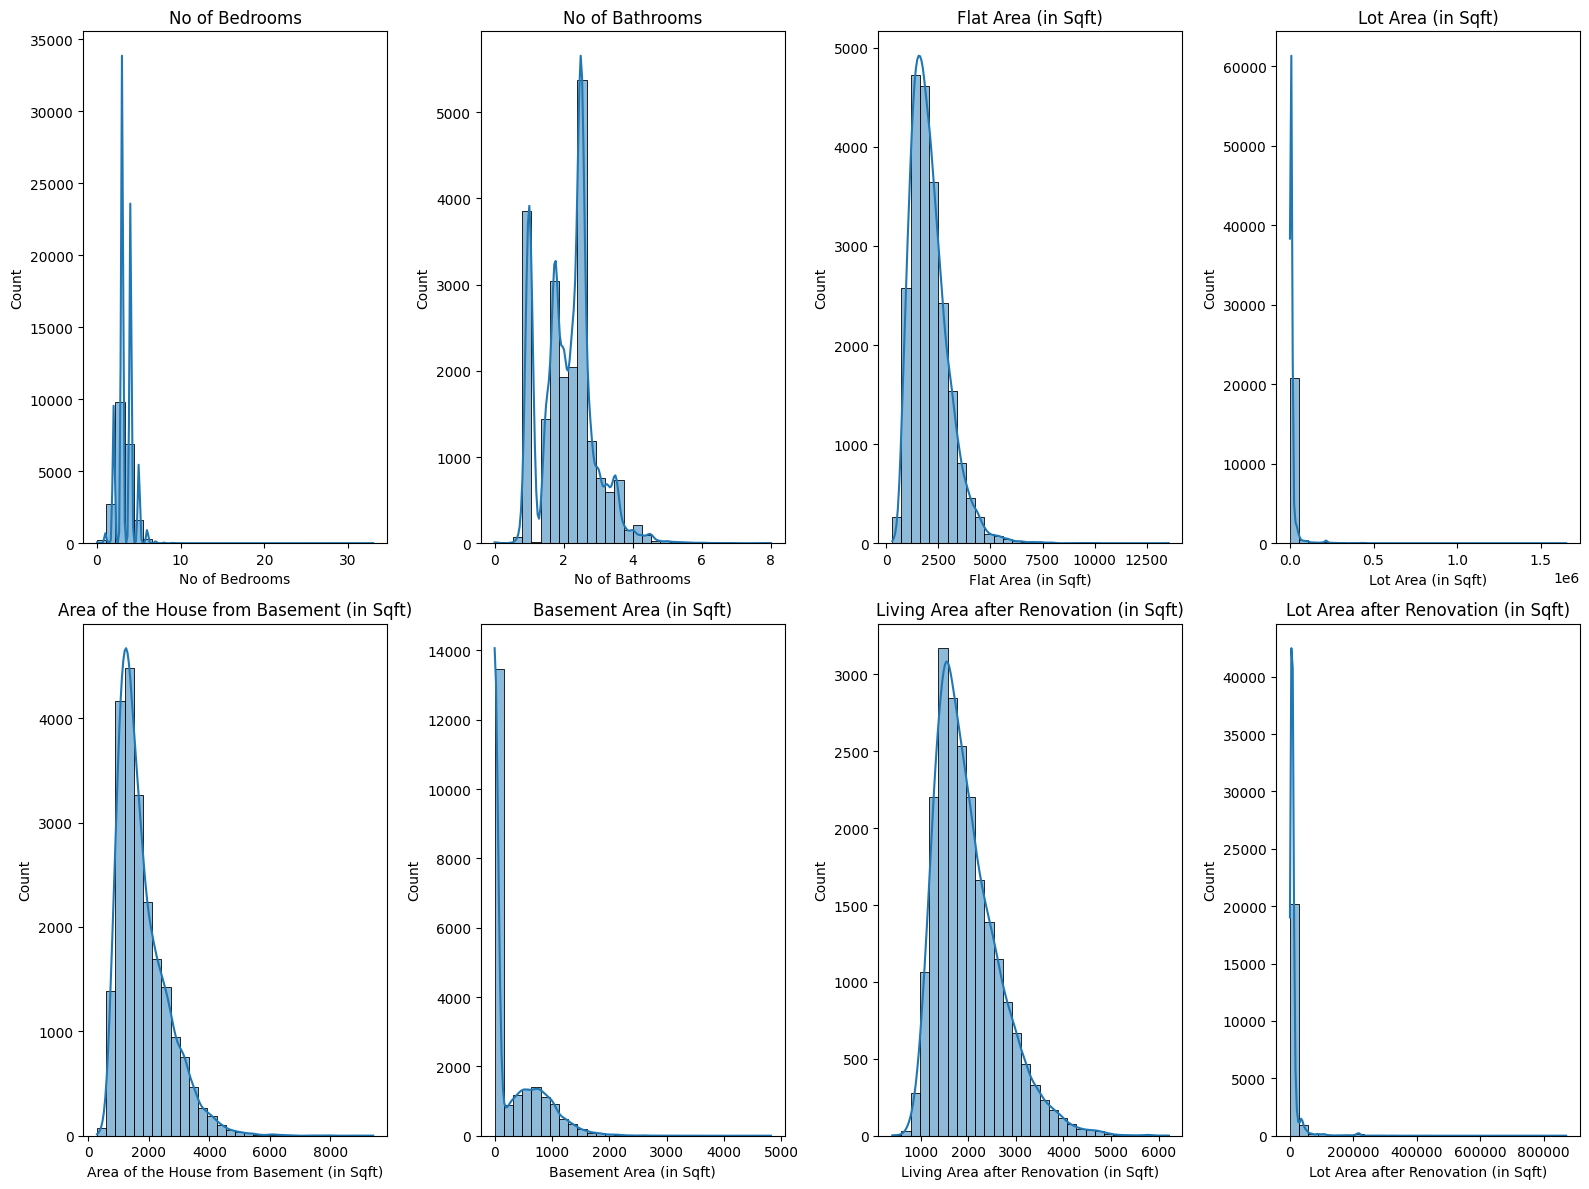

In [261]:
# Drawing histograms of the 8 columns

plt.figure(figsize=(16, 12))

i = 1
for column in num_cols_outliers:
  plt.subplot(2, 4, i)              # i only denotes the position of the histplot while subplotting
  sns.histplot(num_cols_outliers[column], kde=True, bins=30)
  plt.title(column)
  i += 1

plt.tight_layout()
plt.show()

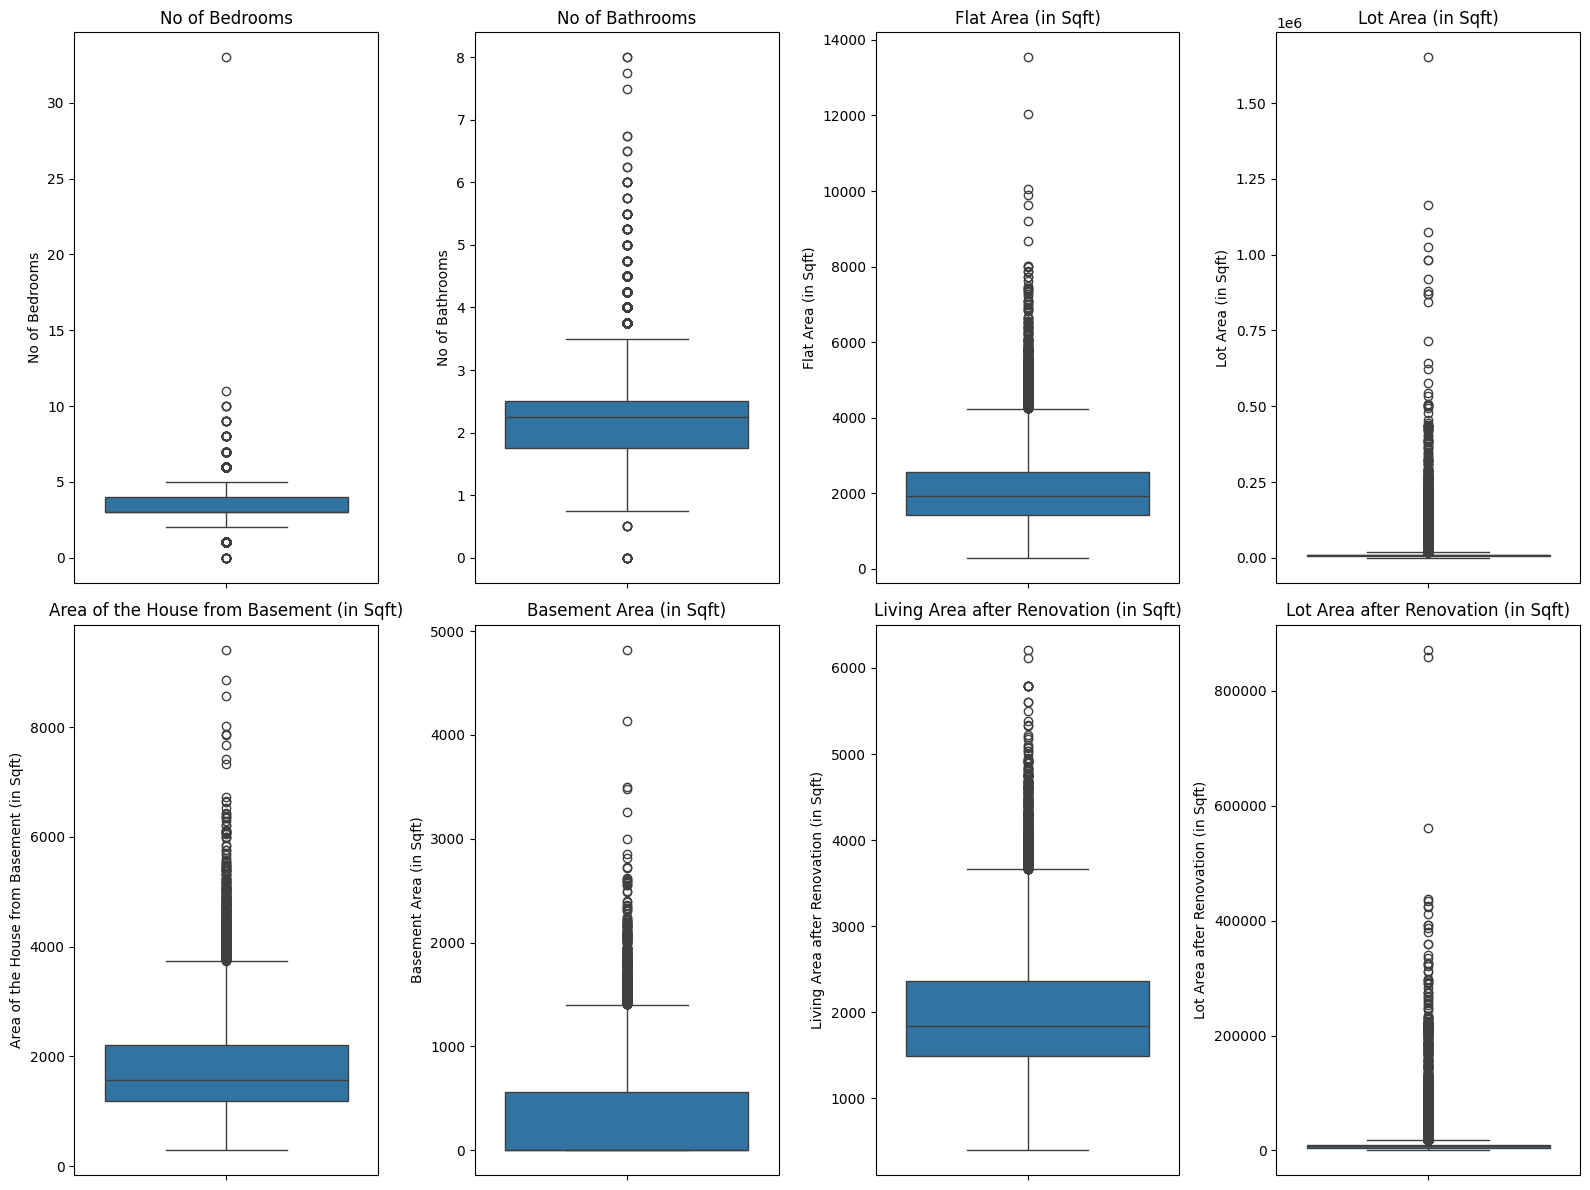

In [262]:
# Boxplots of the 8 columns

plt.figure(figsize=(16, 12))

i = 1
for column in num_cols_outliers:
  plt.subplot(2, 4, i)              # i only denotes the position of the boxplot while subplotting
  sns.boxplot(num_cols_outliers[column])
  plt.title(column)
  i += 1

plt.tight_layout()
plt.show()

In [263]:
# 'No of Bedrooms': Categorical Col with discrete numeric int values
# => skewed graph with long right tail
df_house_prices['No of Bedrooms'].value_counts()

,count
No of Bedrooms,
3,9821
4,6880
2,2758
5,1601
6,271
1,199
7,38
0,13
8,13


In [264]:
df_house_prices['No of Bedrooms'] = df_house_prices['No of Bedrooms'].clip(upper=11)

# But the value=33 is extremely distant from other values
# So we clip only 33 to the value 11

# After clipping
df_house_prices['No of Bedrooms'].unique()

array([ 3,  2,  4,  5,  1,  6,  7,  0,  8,  9, 11, 10])

In [265]:
# 'No of Bathrooms': Categorical Col with large no of unique float values
# Range = 8, min = 0, max = 8, mean = 2

# there isn't much outlier values in this case

df_house_prices['No of Bathrooms'].value_counts()

,count
No of Bathrooms,
2.50,5380
1.00,3850
1.75,3048
2.25,2045
2.00,1930
1.50,1445
2.75,1184
3.00,752
3.50,730


In [266]:
# Creating groups for all unique values in 'No of Bathrooms',
  # then finding mean of 'Sale Price' for each group,
  # then sorting the groups by ascending order of 'No of Bathrooms'

df_house_prices.groupby('No of Bathrooms')['Sale Price'].mean().sort_index()

,Sale Price
No of Bathrooms,
0.00,4.490950e+05
0.50,2.373750e+05
0.75,2.945209e+05
1.00,3.469989e+05
1.25,6.217722e+05
1.50,4.093176e+05
1.75,4.549158e+05
2.00,4.579050e+05
2.25,5.338581e+05


In [267]:
# Most values lie in the range 0-5, remaining values >5 are less in comparison
# But there is a clear upward trend in Sales Price as No of Bathroom increases
# So values >5 are genuine important data
# So we don't perform outlier handling here

In [268]:
# 'Flat Area (in Sqft)': Continuous Numeric Col
# Histogram is right-skewed with somewhat long right-tail
# There are 2 values (near 12k and 14k) that are more distant from other outlier values from the boxplot
# But we still have to infer to decide on outlier handling

# To find largest n vales in Flat Area
large_flat_area = df_house_prices['Flat Area (in Sqft)'].nlargest(5)
large_flat_area

,Flat Area (in Sqft)
12777,13540.0
7252,12050.0
3914,10040.0
9254,9890.0
8092,9640.0


In [269]:
# Higher flat area doesn't necessarily mean higher Sale Price

df_house_prices[['Flat Area (in Sqft)', 'Sale Price']].nlargest(20, 'Flat Area (in Sqft)')

,Flat Area (in Sqft),Sale Price
12777,13540.0,2280000.0
7252,12050.0,7700000.0
3914,10040.0,7060000.0
9254,9890.0,6890000.0
8092,9640.0,4670000.0
4411,9200.0,5570000.0
14556,8670.0,2890000.0
18302,8020.0,3300000.0
1164,8010.0,5110000.0
1448,8000.0,5350000.0


In [270]:
df_house_prices.nlargest(10, 'Flat Area (in Sqft)')

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
12777,1225069038,14 May 2017,2280000.0,7,8.00,13540.0,307752.0,3.0,No,Fair,10,9410.0,4130,19,0,98053.0,47.6675,-121.986,4850.0,217800
7252,6762700020,14 October 2017,7700000.0,6,8.00,12050.0,27600.0,2.5,No,Good,2,8570.0,3480,108,1987,98102.0,47.6298,-122.323,3940.0,8800
3914,9808700762,14 June 2017,7060000.0,5,4.50,10040.0,37325.0,2.0,Yes,Fair,10,7680.0,2360,78,2001,98004.0,47.6500,-122.214,3930.0,25449
9254,9208900037,14 September 2017,6890000.0,6,7.75,9890.0,31374.0,2.0,No,Fair,2,8860.0,1030,17,0,98039.0,47.6305,-122.240,4540.0,42730
8092,1924059029,14 June 2017,4670000.0,5,6.75,9640.0,13068.0,1.0,Yes,Fair,10,4820.0,4820,35,2009,98040.0,47.5570,-122.210,3270.0,10454
4411,2470100110,14 August 2017,5570000.0,5,5.75,9200.0,35069.0,2.0,No,Fair,2,6200.0,3000,17,0,98039.0,47.6289,-122.233,3560.0,24345
14556,2303900035,14 June 2017,2890000.0,5,6.25,8670.0,64033.0,2.0,No,Fair,2,6120.0,2550,53,2003,98177.0,47.7295,-122.372,4140.0,81021
18302,6072800246,14 July 2017,3300000.0,5,6.25,8020.0,21738.0,2.0,No,Fair,10,8020.0,0,17,0,98006.0,47.5675,-122.189,4160.0,18969
1164,1247600105,14 October 2017,5110000.0,5,5.25,8010.0,45517.0,2.0,Yes,Fair,10,5990.0,2020,19,0,98033.0,47.6767,-122.211,3430.0,26788
1448,8907500070,15 April 2016,5350000.0,5,5.00,8000.0,23985.0,2.0,No,Fair,10,6720.0,1280,9,0,98004.0,47.6232,-122.220,4600.0,21750


In [271]:
# It's necessary to let the model know that higher flat !=> higher sale price.
# So we don't outlier handle 'Flat Area (in Sqft)'

# If linear regression is being done, then we can consider log transformation
  # later while Feature Engineering to handle the skewness
# But the Col can be left as is if were doing RandomForest or DecisionTree etc.

In [272]:
# 'Lot Area (in Sqft)': Continuous Numeric Col
# Histogram is extremely right-skewed with very long tail
# We use log-transformation to scale the values without capping/affecting the outliers
# And this columns doesn't contain any 0 values so

df_house_prices['Lot Area (in Sqft)'] = np.log(df_house_prices['Lot Area (in Sqft)'])

<Axes: xlabel='Lot Area (in Sqft)', ylabel='Count'>

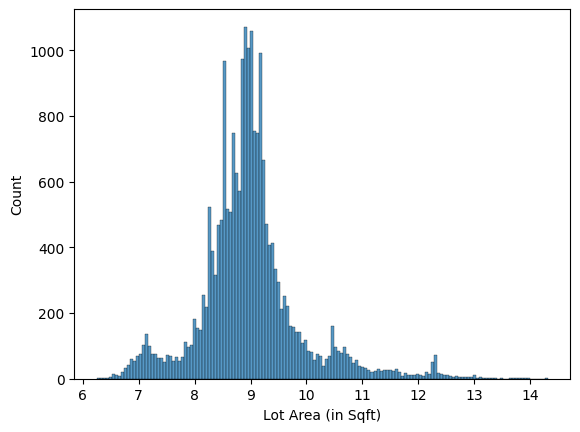

In [273]:
# After Log transformation
sns.histplot(df_house_prices['Lot Area (in Sqft)'])

In [274]:
# 'Area of the House from Basement (in Sqft)': Continuous Numeric Col
# Histogram is right-skewed with somewhat long right-tail
# But tail is having genuine data just like in 'Flat Are (in Sqft)'
# So we skip outlier handling here also

# If linear regression is being done, then we can consider log transformation
  # later while Feature Engineering to handle the skewness
# But the Col can be left as is if were doing RandomForest or DecisionTree etc.

In [275]:
# 'Basement Area (in Sqft)': Continous Numeric Col
# But majority rows has Basement Area = 0, but some cols have extreme high values

# But large basements in large homes are genuine data points
# To find largest n vales in Basement Area
large_basements = df_house_prices['Basement Area (in Sqft)'].nlargest(20)
large_basements

,Basement Area (in Sqft)
8092,4820
12777,4130
15482,3500
7252,3480
10085,3260
4411,3000
5049,2850
21344,2810
7035,2730
6628,2720


In [276]:
df_house_prices[['Basement Area (in Sqft)','Flat Area (in Sqft)', 'Lot Area (in Sqft)', 'Sale Price']].nlargest(20, 'Basement Area (in Sqft)')

,Basement Area (in Sqft),Flat Area (in Sqft),Lot Area (in Sqft),Sale Price
8092,4820,9640.0,9.477922,4670000.0
12777,4130,13540.0,12.637050,2280000.0
15482,3500,7000.0,10.247290,3200000.0
7252,3480,12050.0,10.225571,7700000.0
10085,3260,6510.0,9.709357,1900000.0
4411,3000,9200.0,10.465073,5570000.0
5049,2850,5700.0,9.903488,1390000.0
21344,2810,6880.0,12.542431,1490000.0
7035,2730,7050.0,10.665228,3800000.0
6628,2720,5440.0,12.386643,850000.0


In [277]:
# This shows that 'Basement Area' values are ≈ 50% of the Flat Area values
# So we apply the same deduction for Flat Area here as the extreme values are genuine
# Skip outlier handling for 'Basement Area (in Sqft)'

# But since majority houses have 0 Basements,
  # it may be required to create a new binary feature column under Feature Engineering
  # called 'Has_Basement' to specify if basement is present or not

In [278]:
# 'Living Area after Renovation (in Sqft)': Continous Numerical Col
# => Right-Skewed with gradual tail
# The extreme values are genuine and not handled

# If we're using Regression, this column can be long transformed under Feature Engineering

In [279]:
# 'Lot Area after Renovation (in Sqft)': Continuous Numerical Col
# Histogram is extremely right-skewed with very long tail
# We use log-transformation to scale the values without capping/affecting the outliers
# And this columns doesn't contain any 0 values so

df_house_prices['Lot Area after Renovation (in Sqft)'] = np.log(df_house_prices['Lot Area after Renovation (in Sqft)'])

In [280]:
# df_house_prices[['Lot Area (in Sqft)', 'Lot Area after Renovation (in Sqft)']]

In [281]:
# df_house_prices[['Flat Area (in Sqft)', 'Living Area after Renovation (in Sqft)']]

## Data Transformation

In [282]:
num_cols = df_house_prices[num_cols_outliers.columns]
print(num_cols.columns.tolist())
print(cat_cols.columns.tolist())

['No of Bedrooms', 'No of Bathrooms', 'Flat Area (in Sqft)', 'Lot Area (in Sqft)', 'Area of the House from Basement (in Sqft)', 'Basement Area (in Sqft)', 'Living Area after Renovation (in Sqft)', 'Lot Area after Renovation (in Sqft)']
['Date House was Sold', 'Waterfront View', 'Condition of the House']


In [283]:
# Modifying num_cols and cat_cols based on continuous or discrete numerical value cols

discrete_num_cols = ['ID', 'No of Bedrooms', 'No of Bathrooms', 'No of Floors', 'Overall Grade', 'Age of House (in Years)', 'Renovated Year', 'Zipcode', 'Latitude', 'Longitude']
num_cols = num_cols.drop(columns=['No of Bedrooms', 'No of Bathrooms'], axis=1)
cat_cols = pd.concat([cat_cols, df_house_prices[discrete_num_cols]])

In [284]:
print(num_cols.columns.tolist())
print(cat_cols.columns.tolist())

['Flat Area (in Sqft)', 'Lot Area (in Sqft)', 'Area of the House from Basement (in Sqft)', 'Basement Area (in Sqft)', 'Living Area after Renovation (in Sqft)', 'Lot Area after Renovation (in Sqft)']
['Date House was Sold', 'Waterfront View', 'Condition of the House', 'ID', 'No of Bedrooms', 'No of Bathrooms', 'No of Floors', 'Overall Grade', 'Age of House (in Years)', 'Renovated Year', 'Zipcode', 'Latitude', 'Longitude']


In [285]:
# Cross checking

print(num_cols.shape[1])
print(cat_cols.shape[1])
df_house_prices.shape

6
13


(21605, 20)

### Scaling

In [ ]:
# Manually Identify target col, and put remaining non-numeric cols as feature cols
target_col = ['Sale Price']
# Target col is not scaled because it's the target

In [286]:
# Create lists of continuous numerical columns with sysmmetric and skewed dists. for determining scaling method
minmax_cols = num_cols.columns.tolist()
minmax_cols

['Flat Area (in Sqft)',
 'Lot Area (in Sqft)',
 'Area of the House from Basement (in Sqft)',
 'Basement Area (in Sqft)',
 'Living Area after Renovation (in Sqft)',
 'Lot Area after Renovation (in Sqft)']

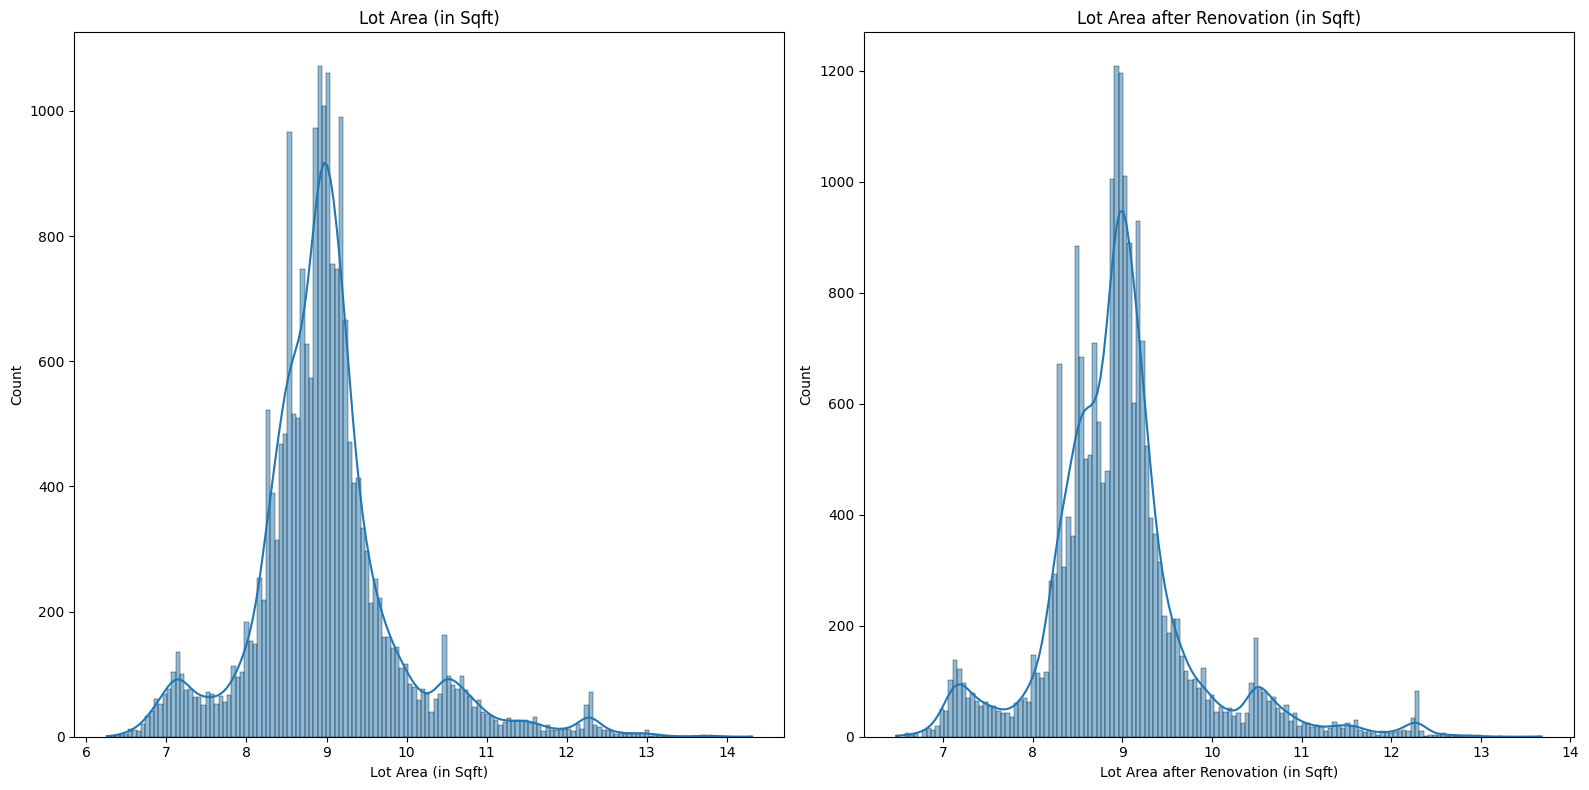

In [287]:
plt.figure(figsize=(16,8))

i=1
for column in num_cols[['Lot Area (in Sqft)', 'Lot Area after Renovation (in Sqft)']]:
  plt.subplot(1, 2, i)
  sns.histplot(num_cols[column], kde=True)
  plt.title(column)
  i += 1

plt.tight_layout()
plt.show()

In [288]:
# Before minmax scaling
df_house_prices[minmax_cols].head()

,Flat Area (in Sqft),Lot Area (in Sqft),Area of the House from Basement (in Sqft),Basement Area (in Sqft),Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,1180.0,8.639411,1180.0,0,1340.0,8.639411
1,2570.0,8.887653,2170.0,400,1690.0,8.941022
2,770.0,9.210340,770.0,0,2720.0,8.994917
3,1960.0,8.517193,1050.0,910,1360.0,8.517193
4,1680.0,8.997147,1680.0,0,1800.0,8.923058


In [289]:
# Creating an object of the MinMax Class to use for scaling
minmax_scaler = MinMaxScaler()

df_house_prices[minmax_cols] = minmax_scaler.fit_transform(df_house_prices[minmax_cols])

In [290]:
# After minmax scaling
df_house_prices[minmax_cols].head()

,Flat Area (in Sqft),Lot Area (in Sqft),Area of the House from Basement (in Sqft),Basement Area (in Sqft),Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,0.067170,0.295858,0.097588,0.000000,0.161934,0.300162
1,0.172075,0.326644,0.206140,0.082988,0.222165,0.342058
2,0.036226,0.366664,0.052632,0.000000,0.399415,0.349544
3,0.126038,0.280700,0.083333,0.188797,0.165376,0.283185
4,0.104906,0.340224,0.152412,0.000000,0.241094,0.339562


### Encoding

In [296]:
# For identifying feature cols;
  # 'ID' - only used to specify the house/row. No use in prediction. Can be dropped from feature columns


feature_cols = df_house_prices[cat_cols.columns].drop(columns=['ID'], axis=1).columns.tolist()
feature_cols



['Date House was Sold',
 'Waterfront View',
 'Condition of the House',
 'No of Bedrooms',
 'No of Bathrooms',
 'No of Floors',
 'Overall Grade',
 'Age of House (in Years)',
 'Renovated Year',
 'Zipcode',
 'Latitude',
 'Longitude']

In [308]:
df_house_prices.drop(columns=['ID'], axis=1, inplace=True)                # Permanently removing redundant column

In [298]:
# Identifying binary feature columns
df_house_prices['Waterfront View'].unique()

array(['No', 'Yes'], dtype=object)

#### Label encoding

In [299]:
# Object
label_encoder = LabelEncoder()    # Only for target col and binary feature cols

df_house_prices['Waterfront View'] = label_encoder.fit_transform(df_house_prices['Waterfront View'])

In [300]:
# After label encoding
df_house_prices['Waterfront View'].head()

,Waterfront View
0,0
1,0
2,0
3,0
4,0


#### Ordinal Encoding

In [303]:
print(df_house_prices['Condition of the House'].unique())
print(df_house_prices['Overall Grade'].unique())

['Fair' 'Excellent' 'Good' 'Bad' 'Okay']
[ 7  6  8 10  9  5  4  3  2  1]


In [304]:
# creating custom order for these 2 columns
condition_order = ['Bad', 'Okay', 'Fair', 'Good', 'Excellent']
grade_order = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

In [305]:
# creating object
ordinal_encoder = OrdinalEncoder(categories=[condition_order, grade_order])

# Apply to both columns simultaneously
df_house_prices[['Condition of the House', 'Overall Grade']] = ordinal_encoder.fit_transform(
    df_house_prices[['Condition of the House', 'Overall Grade']]
)

#### One-Hot Encoding

In [ ]:
# No need because
  # remaining feature columns like Zipcode, Longitude, Latitude etc contain unique discrete tnumerical data already

# Train Test Split

In [310]:
print(df_house_prices.isnull().sum())
df_house_prices.shape

Date House was Sold                          0
Sale Price                                   0
No of Bedrooms                               0
No of Bathrooms                              0
Flat Area (in Sqft)                          0
Lot Area (in Sqft)                           0
No of Floors                                 0
Waterfront View                              0
Condition of the House                       0
Overall Grade                                0
Area of the House from Basement (in Sqft)    0
Basement Area (in Sqft)                      0
Age of House (in Years)                      0
Renovated Year                               0
Zipcode                                      0
Latitude                                     0
Longitude                                    0
Living Area after Renovation (in Sqft)       0
Lot Area after Renovation (in Sqft)          0
dtype: int64


(21605, 19)

In [311]:
print(df_house_prices.dtypes)

Date House was Sold                           object
Sale Price                                   float64
No of Bedrooms                                 int64
No of Bathrooms                              float64
Flat Area (in Sqft)                          float64
Lot Area (in Sqft)                           float64
No of Floors                                 float64
Waterfront View                                int64
Condition of the House                       float64
Overall Grade                                float64
Area of the House from Basement (in Sqft)    float64
Basement Area (in Sqft)                      float64
Age of House (in Years)                        int64
Renovated Year                                 int64
Zipcode                                      float64
Latitude                                     float64
Longitude                                    float64
Living Area after Renovation (in Sqft)       float64
Lot Area after Renovation (in Sqft)          f

In [314]:
# Separate features and target
X = df_house_prices.drop(target_col, axis=1)
y = df_house_prices[target_col]

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Verify shapes
print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")

X_train: (17284, 18)
X_test:  (4321, 18)
y_train: (17284, 1)
y_test:  (4321, 1)
